# Studio di funzione razionale fratta con SymPy

In questo Notebook useremo Python e la sua libreria di calcolo simbolico [SymPy](http://www.sympy.org/en/index.html). Ci limiteremo allo studio di una semplice funzione razionale fratta, a titolo d'esempio, per scoprire alcuni strumenti utili. Gli studenti sono invitati ad approfondirli per ampliare il codice e renderlo in grado di lavore con funzioni più complesse.

Come prima cosa, importiamo dalla libreria tutto quello che ci serve:

In [34]:
from sympy import *
from sympy.plotting import plot
from sympy.solvers.solvers import denoms
from sympy.solvers.inequalities import reduce_rational_inequalities

In particolare, vediamo cosa abbiamo importato e perché.

Con:
`from sympy import *`  
abbiamo importato tutte le funzioni da sympy che utilizzeremo. Con:  
`from sympy.plotting import plot`  
abbiamo importato dalla libreria la funzione per fare il grafico. Con:  
`from sympy.solvers.solvers import denoms`  
abbiamo importato le funzione per riconoscere il denominatore nella funzione e trovarne le soluzioni. Con:  
`from sympy.solvers.inequalities import reduce_rational_inequalities`  
infine, abbiamo importato la funzione per risolvere disequazioni razionali.

Dobbiamo ora definire la variabile reale x:

In [3]:
x=symbols('x', real=True)

Siamo ora pronti a definire la funzione che vogliamo studiare, ossia la funzione:
$$
f(x) = \frac{3-x^2}{(x-2)^2}
$$

In [4]:
f = (3-x**2)/(x-2)**2

Andiamo dunque ad eseguire tutti i passi di uno studio di funzione, ossia:
* Dominio
* Simmetrie
* Intersezioni con gli assi
* Segno
* Asintoti
* Derivate
* Grafico

## Dominio
Il dominio di una funzione razionale fratta si trova semplicemente andando a cercare gli zeri del denominatore, ossia quel o quei valori di $x$ tali che annullano il denominatore.  
Per fare questo usiamo la funzione `denom()` per far individuare il denominatore, all'interno della funzione `solve()` per la ricerca delle soluzioni. La sintassi della funzione `solve()` ci chiede di specificare sia la funzione di cui deve trovare le soluzioni, sia la variabile. Avremo dunque:

In [5]:
sing = solve(denoms(f),x)

Abbiamo salvato il risultato in `sing` (singolarità), di modo che possa essere riutilizzato nel corso del nostro studio. Intanto, stampiamo questo risultato:

In [6]:
print(sing)

[(2,)]


Dunque il Dominio sarà tutto l'insieme Reale, tranne x = 2.

## Simmetrie
Per lo studio di eventuali simmetrie, è sufficiente verificare se $f(-x)$ sia o meno uguale a $f(x)$, a $-f(x)$ o nessuna delle due. Usiamo dunque la funzione `f.subs(x,-x)` per chiedere di sostituire, in $f$, la variabile $x$ con $-x$. Utilizzando poi delle condizioni `if` faremo in modo di fare il controllo descritto precedentemente e stampare direttamente la risposta che cerchiamo.

In [7]:
if f.subs(x,-x)==f:
    sim = 'pari'
elif f.subs(x,-x)==-f:
    sim = 'dispari'
else:
    sim = 'ne pari ne dispari'
print('  La funzione è',sim)

  La funzione è ne pari ne dispari


## Intersezioni con gli assi
Cerchiamo, separatamente, le eventuali intersezioni con gli assi $x$ ed $y$.
### Asse $x$
dobbbiamo semplicemente risolvere l'equazione: $$f(x)=0$$

In [8]:
intx = solve(f,x)
print(intx)

[-sqrt(3), sqrt(3)]


### Asse $y$
Dobbiamo risolvere: $$y=f(0)$$

In [9]:
inty = f.subs(x,0)
print(inty)

3/4


Come avrete notato, abbiamo usato due funzioni già viste in precedenza.

## Segno
Dobbiamo semplicemente studiare la disequazione: $$ f(x)\ge 0 $$

In [10]:
sign = reduce_rational_inequalities([[f >= 0]],x)
print(sign)

(x <= sqrt(3)) & (-sqrt(3) <= x)


## Asintoti
### Asintoti verticali
Cerchiamo per primi gli eventuali asintoti verticali. Se abbiamo trovato delle singolarità, ossia se `sing` è non nullo, dovremo fare i limiti per ognuna delle singolarità. Ossia, se chiamiamo $x_s$ un punto di singolarità, avremo che se:
$$ \lim_{x \to x_s}{f(x)} = \pm \infty $$
allora $x = x_s$ è un asintoto verticale. Dunque dovremo iterare su tutti i punti contenuti in `sing` facendo i limiti. In particolare dovremmo verificare separatamente il limite destro e limite sinistro. Nel nostro caso, l'unico punto è $x=2$. Quindi dovremo verificare che:
$$ \lim_{x \to 2^+}{f(x)} = \pm \infty \;\;\mbox{e}\;\; \lim_{x \to 2^-}{f(x)} = \pm\infty$$

Da notare che *infinito* in SymPy si indica con `oo`.

In [15]:
asved = limit(f, x, 2, '+')
asves = limit(f, x, 2, '-')
print('Limite destro = ', asved)
print('Limite sinistro = ', asves)
if (asved == oo or asved == -oo) and (asves == oo or asves == -oo):
    print('  - verticale: x =', asve)
else:
    print('  - verticale: Nessuno')

Limite destro =  -oo
Limite sinistro =  -oo
  - verticale: x = (2,)


### Asintoti orizzontali
Sappiamo che per cercare eventuali asintoti orizzontali dobbiamo verificare che:
$$ \lim_{x \to \pm\infty}{f(x)}= l $$
altrimenti potremmo avere un asintoto obliquo. Nel qual caso dovremmo cercare il coefficiente angolare $m$ e il termine noto $q$ della retta asintoto:
$$ m = \lim_{x \to \pm\infty}{\frac{f(x)}{x}} \;\;\mbox{e}\;\; q = \lim_{x \to \pm\infty}{f(x) - mx} $$

In [18]:
asor = limit(f, x, oo)
print('Asintoto orizzontale: y =', asor)

Asintoto orizzontale: y = -1


In questo esempio non abbiamo asintoti obliqui.

## Derivate
### Derivata prima, andamenti, massimi, minimi, flessi orizzontali
Facciamo anzitutto la derivata, utilizzando la funzione `diff`. Usiamo anche `simplify` per avere il risultato già semplificato.

In [36]:
f1 = simplify(diff(f,x))
print('D[f(x)] = ', f1)

D[f(x)] =  4*x/(x - 2)**3 - 6/(x - 2)**3


Ora cerchiamo eventuali punti stazionari e studiamo il segno, ossia:
$$ D[f(x)] \ge 0 $$

In [42]:
puntistaz = solve(f1,x)
signf1 = reduce_rational_inequalities([[f1 >= 0]],x)
print('Punti stazionari: ', puntistaz)
print('D[f(x)] > 0 per: ', signf1)

Punti stazionari:  [3/2]
D[f(x)] > 0 per:  ((x <= 3/2) & (-oo < x)) | ((2 < x) & (x < oo))


Dallo studio del segno si capisce che $x=\frac{3}{2}$ è un massimo.

Passiamo ora alla derivata seconda.

In [43]:
f2 = simplify(diff(f1,x))
flessi = solve(f2,x)
signf2 = reduce_rational_inequalities([[f2 >= 0]],x)
print('Flessi: ', flessi)
print('D2[f(x)] > 0 per: ', signf2)

Flessi:  [5/4]
D2[f(x)] > 0 per:  (x <= 5/4) & (-oo < x)


## Grafico
Non ci manca che fare il grafico mettendo insieme tutte le informazioni.

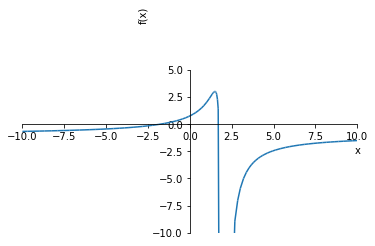

In [40]:
plt = plot(f,(x,-10,10),ylim=(-10,10))